<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/> 

# Regression and Classification: Evaluating Classification Models
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

---
---
# Activity 1 - Metrics for Classification
---
---


For each scenario, decide which metric would be **most appropriate to prioritise**:

**Precision, Recall, or F1 Score**

---

### Question 1 — Fraud Detection

A bank is building a model to detect fraudulent credit card transactions.

If the model incorrectly flags legitimate transactions as fraud (false positives), customers may have their cards blocked and experience inconvenience. However, if fraudulent transactions are missed (false negatives), the bank could suffer financial losses.

The bank is most concerned about **ensuring that flagged transactions are actually fraudulent**, to avoid blocking legitimate customers unnecessarily.

**Which metric should the bank prioritise?** - Precision 

---


### Question 2 — Disease Screening

A hospital is building a model to detect a serious disease in early-stage patients.

If the model misses a true case of the disease (false negative), the patient may not receive treatment in time. If the model incorrectly flags someone as positive (false positive), they will undergo additional medical testing.

Doctors believe it is **much worse to miss a true case than to perform additional tests unnecessarily**.

**Which metric should the hospital prioritise?** - Recall

---


### Question 3 — Spam Email Filtering

An email provider is developing a spam detection system.

If legitimate emails are incorrectly classified as spam (false positives), important messages may be hidden from users. If spam emails are missed (false negatives), users will still receive some unwanted messages.

The company wants to **avoid blocking legitimate emails**, even if some spam still gets through.

**Which metric should the company prioritise?** - Precision

---


### Question 4 — Customer Churn Prediction

A telecommunications company is building a model to predict which customers are likely to leave.

The company plans to offer retention discounts to customers predicted to churn. If the model incorrectly predicts churn (false positive), the company may give discounts unnecessarily. If the model misses a customer who churns (false negative), the company loses future revenue.

Both mistakes have financial costs, and the company wants to **balance capturing churners while avoiding too many unnecessary discounts**.

**Which metric should the company prioritise?** - F1 Score

---

### Question 5 — Security Threat Detection

A national security system is designed to identify potential cyber threats.

If a real threat is missed (false negative), it could lead to serious damage. If a harmless activity is flagged as a threat (false positive), analysts will investigate it, which costs time but does not pose immediate danger.

The organisation believes **missing a true threat is far worse than investigating a false alarm**.
Recall


---
---
# Activity 1B - Interpreting Precision and Recall
---
---


## 1) Recall = 0.90 (screening)

**Scenario:** A clinic uses a model to flag patients who may have a serious condition for a follow-up test.
A candidate model is chosen using **recall = 0.90**. What does this mean?

**A)** It flags **90% of the patients who truly have the condition** (few missed cases). <

**B)** Of the patients it flags, **90% truly have the condition** (very few false alarms).

**C)** It correctly reassures **90% of patients who don’t have the condition**.



## 2) Precision = 0.90 (fraud card freeze)

**Scenario:** A bank flags transactions as fraud; each flag triggers an immediate card freeze, so false alarms are expensive.
A candidate model is chosen using **precision = 0.90**. What does this mean?

**A)** **90% of the frozen transactions are truly fraud** (few false freezes). <

**B)** It catches **90% of all fraud transactions** (almost no fraud missed).

**C)** It correctly approves **90% of genuine transactions**.


## 3) Precision = 0.80 and Recall = 0.70 (safeguarding triage)

**Scenario:** A safeguarding team flags high-risk cases for urgent review; false alarms waste staff time, but missed risks are serious too.
A candidate model is chosen using **precision = 0.80** and **recall = 0.70**. What does this mean?

**A)** Of the cases flagged for urgent review, **80% are truly high-risk**, and the model catches **70% of all true high-risk cases**. <

**B)** The team will correctly review **80% of all cases**, and **70% of all cases** will be flagged as high-risk.

**C)** The model catches **80% of all true high-risk cases**, and **70% of flagged cases** are truly high-risk.



---
---
# Activity 2 - Fiting a Model and Evaluating It
---
---

setup for next activity

In [1]:
#run this cell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

X, y = make_classification(
    n_samples=8000,
    n_features=12,
    n_informative=4,
    n_redundant=2,
    weights=[0.85, 0.15],
    class_sep=0.7,
    flip_y=0.03,
    random_state=42
)

X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(1, 13)])
y = pd.Series(y, name="out_migration")


# Split the dataset into training and testing sets
# The model learns patterns from the training data and is evaluated on the test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                     # X = predictors (features), y = target variable
    test_size=0.3,            # 30% of the data is reserved for testing the model
    stratify=y,               # keeps the class distribution (0/1) the same in both sets
    random_state=42           # ensures the split is reproducible
)


In [3]:
# here we have the same models from class

# Create a logistic regression model
# Logistic regression estimates the probability that an observation belongs to class 1
model_lr = LogisticRegression()

# Train the model using the training data
model_lr.fit(X_train, y_train)


# Create a decision tree model
# A decision tree learns a series of decision rules to classify observations
model_dt = DecisionTreeClassifier(random_state=42)

# Train the decision tree on the training data
model_dt.fit(X_train, y_train)

# Create a random forest model
# A random forest combines many decision trees to improve prediction stability
model_rf = RandomForestClassifier(random_state=42)

# Train the random forest using the training data
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [2]:
# using gen ai or overwise, can you add another model to the mix? maybe a support vector machine or a k-nearest neighbors model and fix it like above?
from sklearn.ensemble import AdaBoostClassifier

# we instantiate the model
abc_model = AdaBoostClassifier(random_state=42)

# fit to training data
abc_model.fit(X_train, y_train)





,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [4]:
# for new model, can you generate the average validation precision after k=5 folds cross validation?
# we use our model with cv=5 and presicion for the scoring
cv_scores_abc = cross_val_score(abc_model, X_train, y_train, cv=5, scoring='precision')

# Convert the cross-validation results into a DataFrame for easier inspection
cv_results_abc = pd.DataFrame(cv_scores_abc)

# Display summary statistics of the validation precision scores across the 5 folds
# This helps us understand the average performance and variability of the model
print(cv_results_abc.describe())

              0
count  5.000000
mean   0.868795
std    0.046508
min    0.805556
25%    0.855670
50%    0.870370
75%    0.877193
max    0.935185


---
---
# Activity 3 - Hyperparameter Tuning With RandomizedSearchCV
---
---

Up until now, we have used **GridSearchCV** to find the best hyperparameters for our models. However, GridSearchCV can be computationally expensive, and we often may not have a good intuition about which hyperparameters to test and in which ranges.

Introducing randomized search for hyperparameter tuning, which allows us to efficiently explore a wide range of hyperparameter combinations by sampling randomly from specified distributions. This method is particularly useful when we have a large hyperparameter space and want to find the best model configuration without exhaustively testing every combination.

In [7]:
# run the code below and see how if it got a higher score than the version in class

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    # log-uniform-ish range: samples values across orders of magnitude
    "C": np.logspace(-4, 4, 50),          # regularisation strength (inverse)
    "penalty": ["l2"],                    # safest default across solvers
    "solver": ["lbfgs"],                  # stable for l2
    "max_iter": [500, 1000]               # avoid non-convergence
}

lr = LogisticRegression(random_state=42)

random_search_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,                            # start small; increase if needed
    scoring="precision",
    cv=cv,
    random_state=42,
    n_jobs=1,                             # reduces memory spike risk
    verbose=1
)

random_search_lr.fit(X_train, y_train)

best_lr = random_search_lr.best_estimator_
print("Best parameters:", random_search_lr.best_params_)
print("Best CV Precision:", random_search_lr.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 500, 'C': np.float64(0.0029470517025518097)}
Best CV Precision: 1.0


How does the performance compare to our previous grid search results? Does it find a better model?

Task (OWN TIME): use gen ai to generate a randomized search for the logistic regression model we have been working with, and compare the results to our previous grid search. make sure to include a decent range for your hyperparameters to get the benefits of randomized search. if you're up for it, you can do a randomized grid search for another model as well like the one you added in the last activity.

In [ ]:
# place your generated code here for logistic regression randomized search


In [ ]:
# place your generated code here for the randomized search for the new model you added

---
# Activity 4 - produce a confusion matriix for the logistic regression model 
---

In [17]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {'solver': ['lbfgs'], 'penalty': ['l2'], 'max_iter': [500], 'C': [np.float64(0.0029470517025518097)]}
lr = LogisticRegression(random_state=42)

random_search_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,                            # start small; increase if needed
    scoring="precision",
    cv=cv,
    random_state=42,
    n_jobs=1,                             # reduces memory spike risk
    verbose=1
)

random_search_lr.fit(X_train, y_train)

best_lr = random_search_lr.best_estimator_
print("Best parameters:", random_search_lr.best_params_)
print("Best CV Precision:", random_search_lr.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 500, 'C': np.float64(0.0029470517025518097)}
Best CV Precision: 1.0


### generate confusion matrix for the logistic regression model

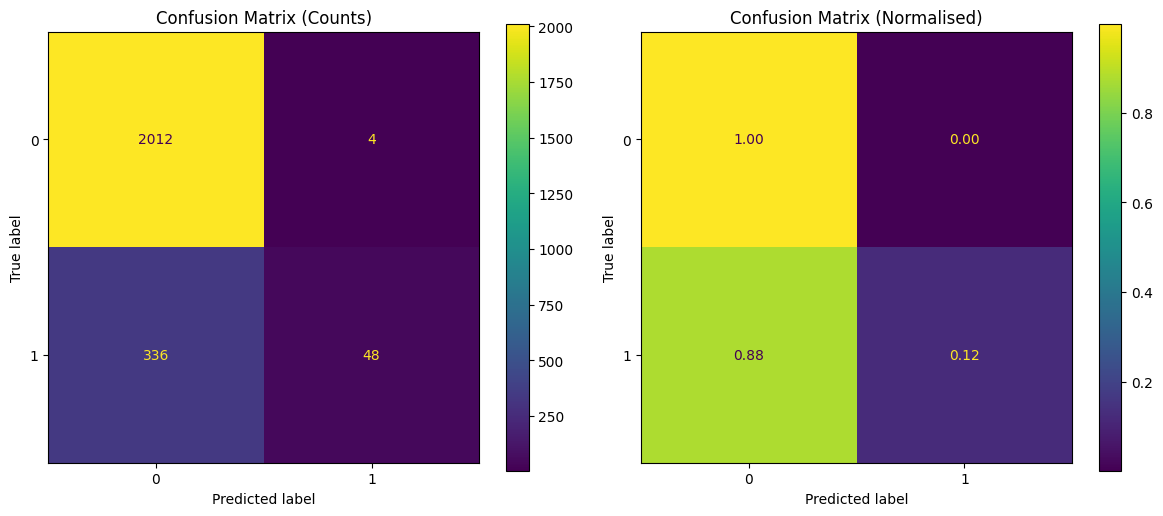

In [19]:
y_pred = best_lr.predict(X_test)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=axes[0],
    values_format="d"
)
axes[0].set_title("Confusion Matrix (Counts)")

# Normalised
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    ax=axes[1],
    values_format=".2f"
)
axes[1].set_title("Confusion Matrix (Normalised)")

plt.tight_layout()
plt.show()

### generate the code for the precision and recall for the logistic regression model

### How does it compare to the one in class